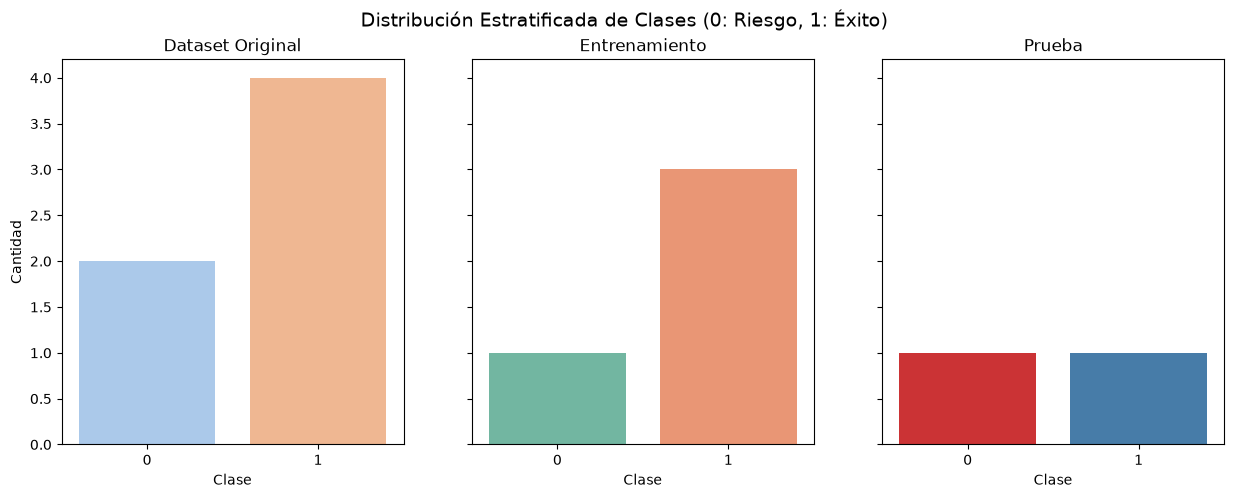

Entrenando modelo y buscando hiperparámetros óptimos...

--- Resultados del Entrenamiento ---
Mejores Hiperparámetros: {'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 50}
Precisión (Accuracy) en entrenamiento CV: 0.75


In [5]:
import sys
import os
import pandas as pd
import importlib
from sklearn.model_selection import train_test_split

sys.path.append(os.path.abspath('../src'))

import feature_eng
import train_model
importlib.reload(feature_eng)
importlib.reload(train_model)

df_limpio = pd.read_csv('../data/processed/estudiantes_limpios.csv')
df_features = feature_eng.engineer_features(df_limpio)
df_modelaje = train_model.prepare_training_data(df_features)

X = df_modelaje.drop('exito_academico', axis=1)
y = df_modelaje['exito_academico']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y
)


train_model.plot_data_split(y, y_train, y_test)

print("Entrenando modelo y buscando hiperparámetros óptimos...")
grid_search_results = train_model.train_random_forest(X_train, y_train)
best_model = grid_search_results.best_estimator_

print("\n--- Resultados del Entrenamiento ---")
print(f"Mejores Hiperparámetros: {grid_search_results.best_params_}")
print(f"Precisión (Accuracy) en entrenamiento CV: {grid_search_results.best_score_:.2f}")

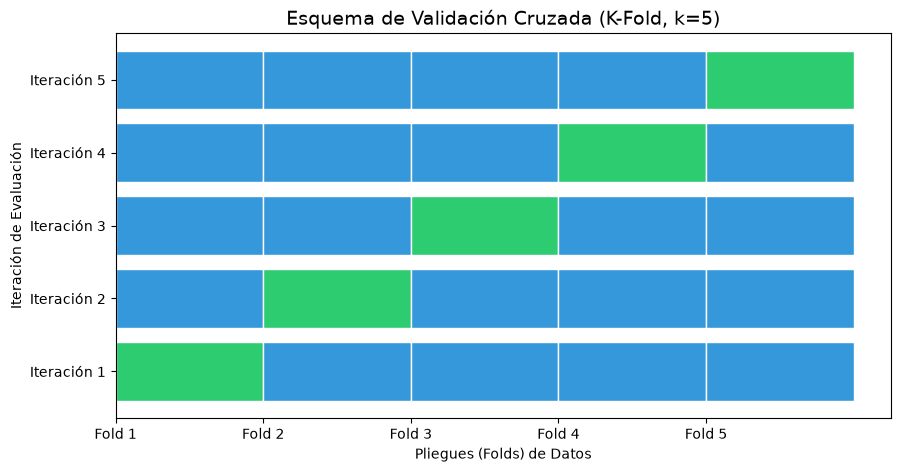


--- Reporte de Clasificación ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



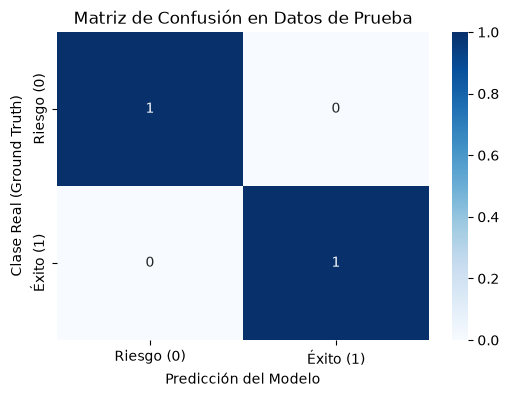

(None,
 None,
 <Figure size 600x400 with 2 Axes>,
 <Axes: title={'center': 'Matriz de Confusión en Datos de Prueba'}, xlabel='Predicción del Modelo', ylabel='Clase Real (Ground Truth)'>,
 Text(0.5, 1.0, 'Matriz de Confusión en Datos de Prueba'),
 Text(0.5, 24.33658854166667, 'Predicción del Modelo'),
 Text(24.33658854166668, 0.5, 'Clase Real (Ground Truth)'),
 None,
 None)

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
from sklearn.metrics import classification_report, confusion_matrix

plot_cv_process = lambda n_splits: (
    plt.figure(figsize=(10, 5)),
    [plt.barh(y=i, width=1, left=np.arange(n_splits), color=['#2ecc71' if j == i else '#3498db' for j in range(n_splits)], edgecolor='white') for i in range(n_splits)],
    plt.title(f'Esquema de Validación Cruzada (K-Fold, k={n_splits})', fontsize=14),
    plt.xlabel('Pliegues (Folds) de Datos'),
    plt.ylabel('Iteración de Evaluación'),
    plt.yticks(range(n_splits), [f'Iteración {i+1}' for i in range(n_splits)]),
    plt.xticks(range(n_splits), [f'Fold {i+1}' for i in range(n_splits)]),
    
    os.makedirs('../reports/figures', exist_ok=True),
    plt.savefig('../reports/figures/cross_validation.png', dpi=300, bbox_inches='tight'),
    plt.show()
)

evaluate_model = lambda model, X_t, y_t: (
    print("\n--- Reporte de Clasificación ---"),
    print(classification_report(y_t, model.predict(X_t), zero_division=0)),

    plt.figure(figsize=(6, 4)),
    sns.heatmap(confusion_matrix(y_t, model.predict(X_t)), annot=True, fmt='d', cmap='Blues', xticklabels=['Riesgo (0)', 'Éxito (1)'], yticklabels=['Riesgo (0)', 'Éxito (1)']),
    plt.title('Matriz de Confusión en Datos de Prueba'),
    plt.xlabel('Predicción del Modelo'),
    plt.ylabel('Clase Real (Ground Truth)'),
    plt.savefig('../reports/figures/confusion_matrix.png', dpi=300, bbox_inches='tight'),
    plt.show()
)

plot_cv_process(5)
evaluate_model(best_model, X_test, y_test)